# $(SA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
186,39,5,"(0.43, 0.0)","(0.152, 0.642, -0.167, -1.491)",1,1.0,"(0.165, 0.844, -0.197, -1.935)",0.0,1.0,"(0.182, 0.648, -0.236, -1.642)"
29,29,0,"(0.18, 1.6)","(-0.095, 0.134, 0.136, 0.177)",1,1.0,"(-0.093, 0.319, 0.14, 0.095)",0.0,1.0,"(-0.086, 0.132, 0.141, 0.205)"
105,4,3,"(0.63, 1.6)","(-0.044, -0.027, 0.031, 0.027)",0,1.0,"(-0.044, -0.216, 0.032, 0.181)",0.0,1.0,"(-0.048, -0.405, 0.036, 0.335)"
147,0,5,"(0.43, 0.0)","(0.031, 0.031, 0.002, -0.021)",0,1.0,"(0.031, -0.169, 0.001, 0.365)",0.0,1.0,"(0.028, -0.368, 0.008, 0.751)"
165,18,5,"(0.43, 0.0)","(0.052, 0.422, 0.0, -0.629)",0,1.0,"(0.061, 0.223, -0.012, -0.243)",0.0,1.0,"(0.065, 0.024, -0.017, 0.138)"
...,...,...,...,...,...,...,...,...,...,...
228,2,9,"(0.92, 0.9)","(0.04, 0.379, 0.003, -0.776)",1,1.0,"(0.048, 0.579, -0.012, -1.181)",0.0,1.0,"(0.059, 0.379, -0.036, -0.78)"
46,46,0,"(0.18, 1.6)","(0.03, 1.05, 0.2, 0.008)",0,1.0,"(0.051, 0.863, 0.2, 0.123)",1.0,1.0,"(0.068, 1.049, 0.202, 0.049)"
12,12,0,"(0.18, 1.6)","(-0.057, -0.416, 0.071, 0.265)",0,1.0,"(-0.065, -0.602, 0.076, 0.369)",0.0,1.0,"(-0.077, -0.789, 0.084, 0.474)"
224,7,8,"(0.68, 1.0)","(0.071, 1.405, -0.124, -1.825)",0,1.0,"(0.099, 1.213, -0.16, -1.609)",1.0,1.0,"(0.123, 1.408, -0.192, -1.897)"


In [ ]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.5525414943695068, 2.814119815826416]","[0.6119496822357178, 2.924285888671875]","[0.13540033996105194, 0.38943490386009216, 0.0...",2.295931,1.433193,0.162979
1,1,"[0.5522674322128296, 2.8101513385772705]","[0.611322283744812, 2.9200565814971924]","[0.1330137550830841, 0.3858622908592224, 0.081...",2.295327,1.418865,0.162752
2,2,"[0.5520183444023132, 2.806135416030884]","[0.6107232570648193, 2.915794610977173]","[0.13065963983535767, 0.38224315643310547, 0.0...",2.294727,1.404699,0.162544
3,3,"[0.5518326163291931, 2.802456855773926]","[0.6101889610290527, 2.911868095397949]","[0.12835370004177094, 0.3786097466945648, 0.07...",2.294180,1.390682,0.162346
4,4,"[0.5517675876617432, 2.799116373062134]","[0.6097797155380249, 2.908292293548584]","[0.12610992789268494, 0.37497034668922424, 0.0...",2.293694,1.376808,0.162155


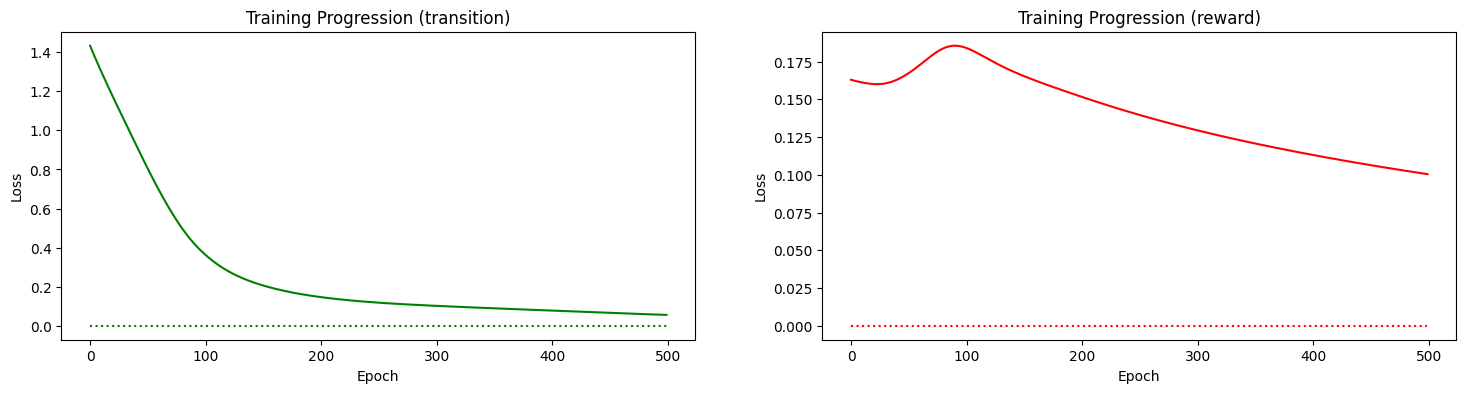

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

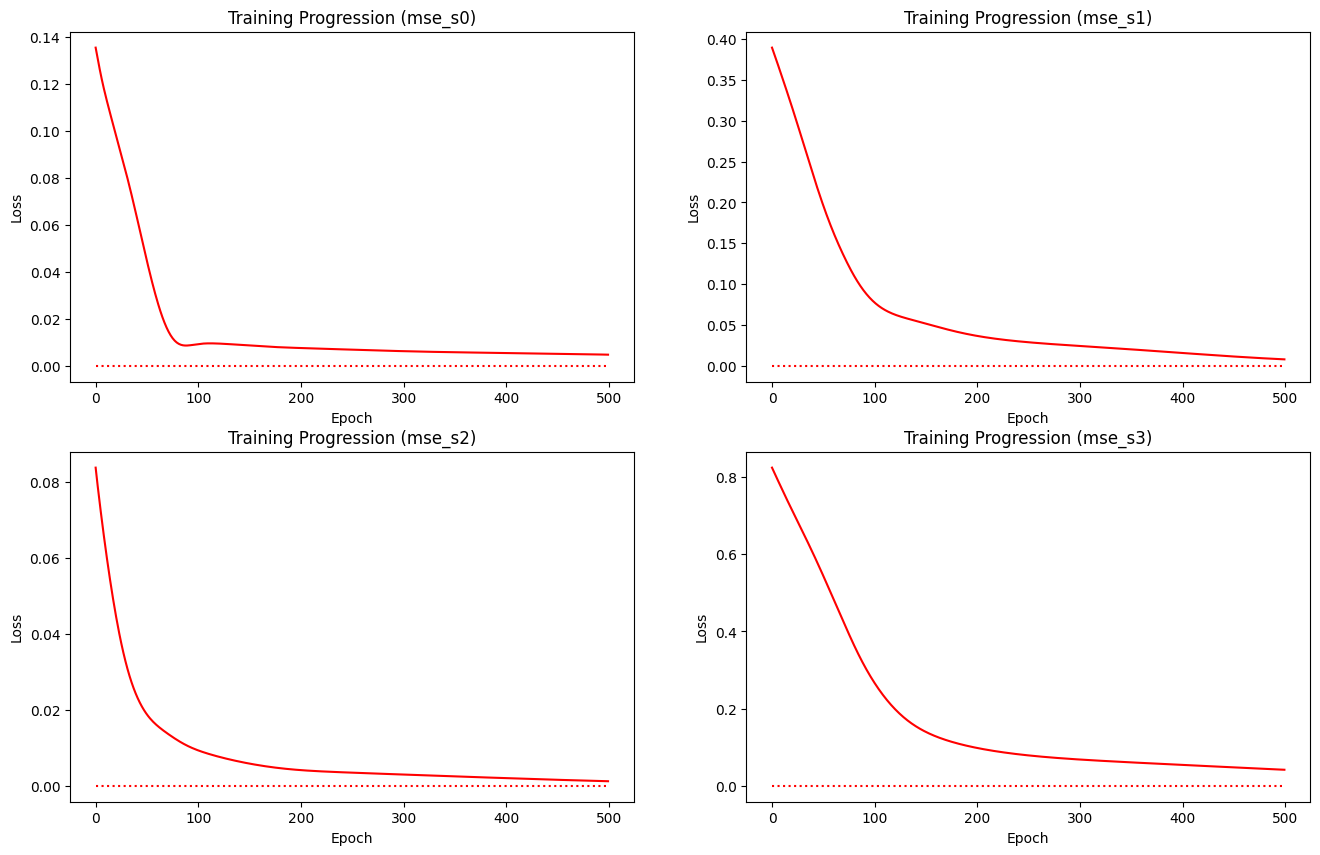

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

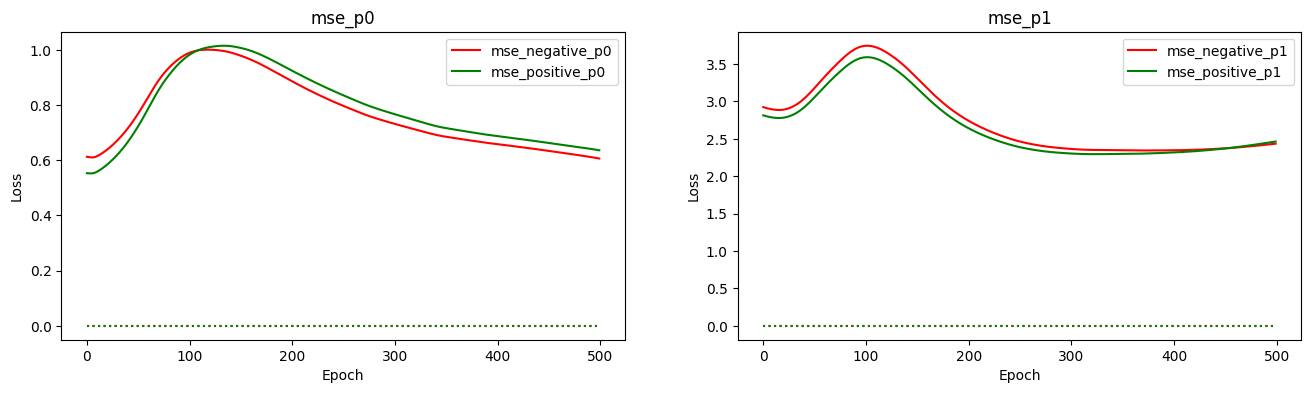

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

# Evaluation

In [7]:
results = data.evaluate_model(model, path='testing_data.csv')
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.49, 0.0)","(0.005, 0.039, -0.028, -0.013)",1,1.0,"(0.006, 0.24, -0.028, -0.434)",1.0,1.0,"(0.011, 0.441, -0.037, -0.856)","(0.035, 0.462, -0.054, -0.634)","(-0.045, -0.209)",0.7
1,1,0,"(0.49, 0.0)","(0.006, 0.24, -0.028, -0.434)",1,1.0,"(0.011, 0.441, -0.037, -0.856)",0.0,1.0,"(0.019, 0.241, -0.054, -0.463)","(0.024, 0.402, -0.057, -0.585)","(-0.245, -0.284)",0.7
2,2,0,"(0.49, 0.0)","(0.011, 0.441, -0.037, -0.856)",0,1.0,"(0.019, 0.241, -0.054, -0.463)",1.0,1.0,"(0.024, 0.442, -0.063, -0.896)","(0.037, 0.462, -0.072, -0.673)","(-0.064, -0.182)",0.7
3,3,0,"(0.49, 0.0)","(0.019, 0.241, -0.054, -0.463)",1,1.0,"(0.024, 0.442, -0.063, -0.896)",1.0,1.0,"(0.033, 0.644, -0.081, -1.331)","(0.053, 0.712, -0.114, -1.104)","(-0.297, -0.238)",0.7
4,4,0,"(0.49, 0.0)","(0.024, 0.442, -0.063, -0.896)",1,1.0,"(0.033, 0.644, -0.081, -1.331)",1.0,1.0,"(0.046, 0.846, -0.108, -1.774)","(0.075, 0.932, -0.15, -1.533)","(-0.645, -0.257)",0.7


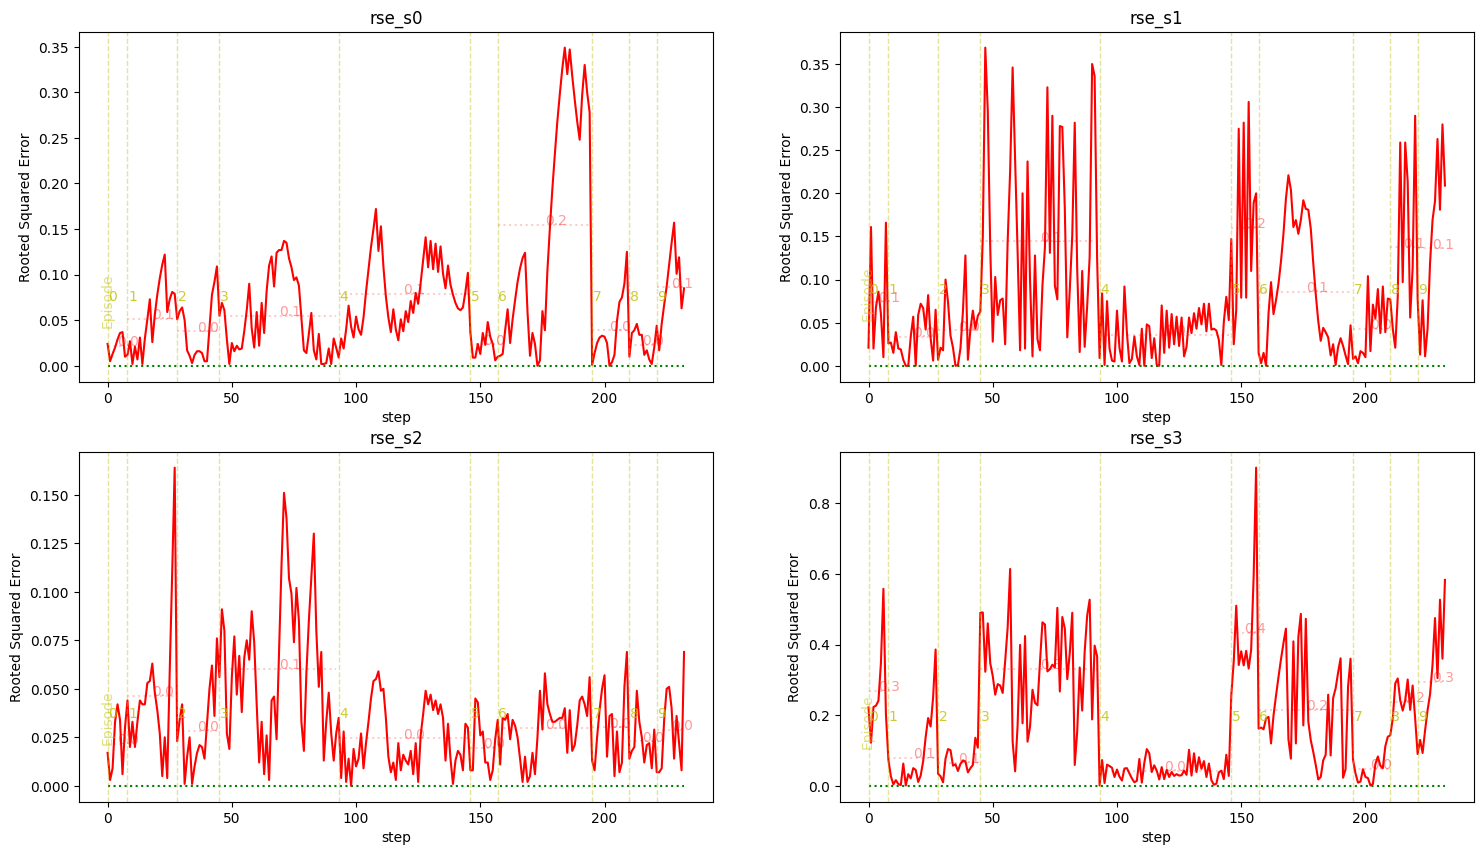

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

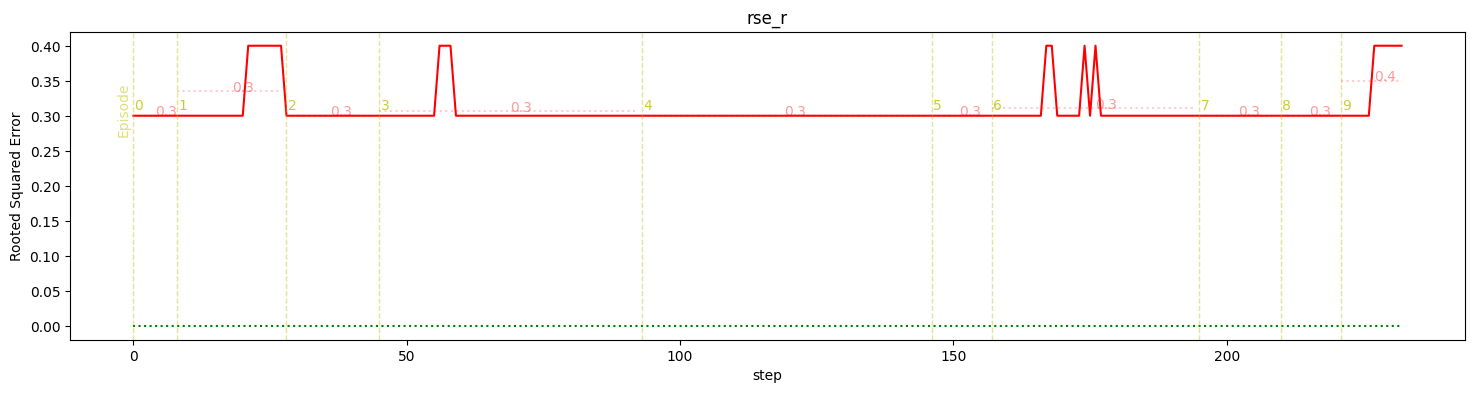

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

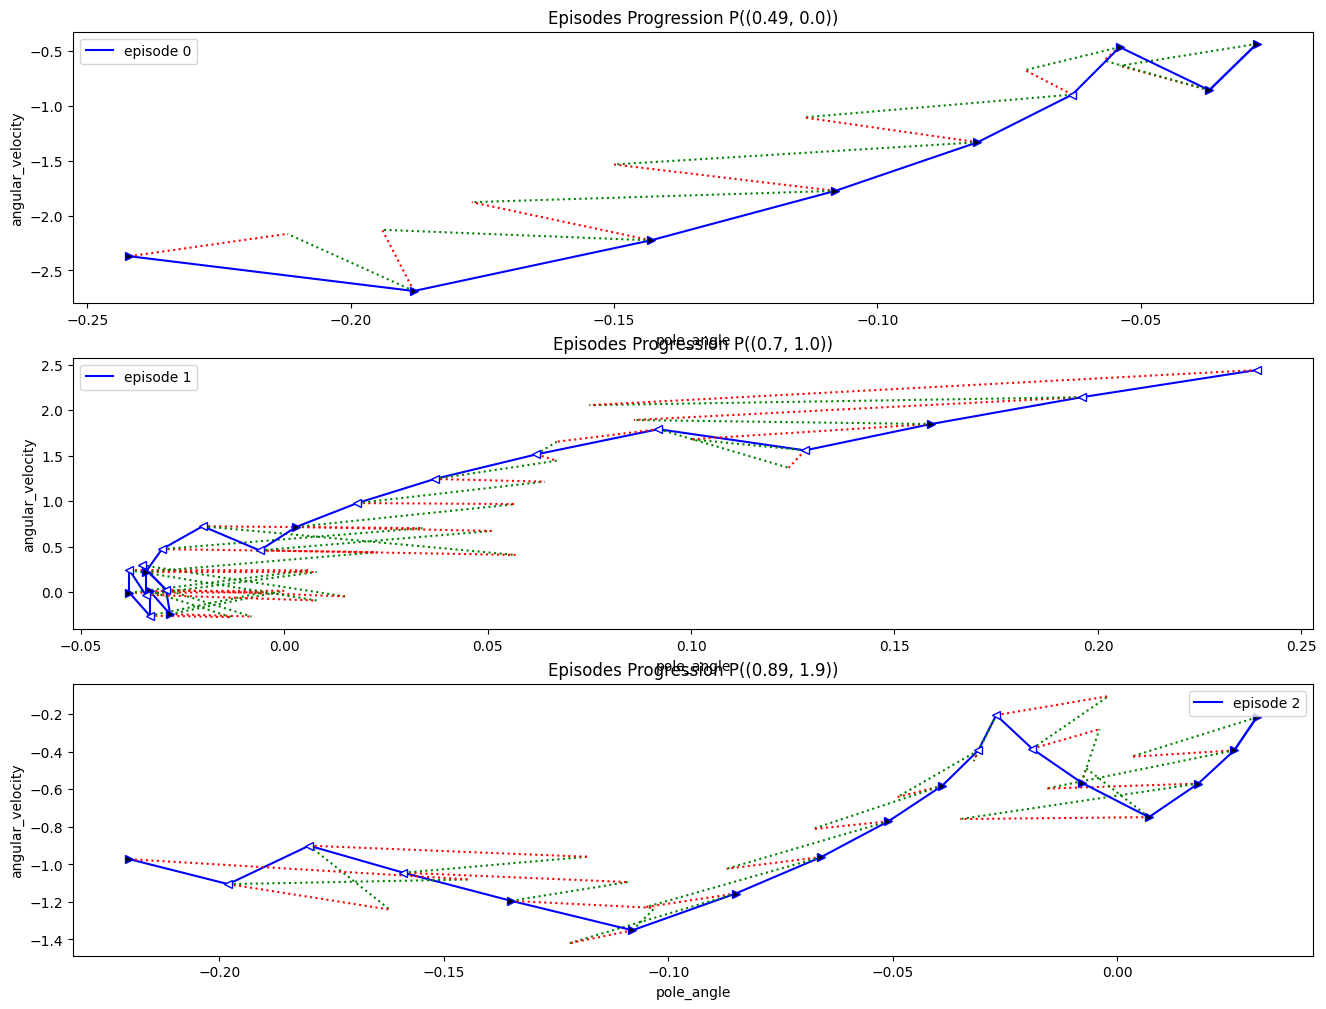

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()